In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score

In [104]:
df=pd.read_csv('youtube_channel_real_performance_analytics.csv')

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [106]:
df.isnull().sum()

ID                         0
Video Duration             0
Video Publish Time         0
Days Since Publish         0
Day                        0
                          ..
Watch Time (hours)         0
Subscribers                0
Estimated Revenue (USD)    0
Impressions                0
Video Thumbnail CTR (%)    0
Length: 70, dtype: int64

In [107]:
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [108]:
df.describe()

,ID,Video Duration,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02,364.000000
mean,181.500000,664.239011,8.406593,15.807692,6.642857,2018.736264,0.112283,8934.711538,1.553734,1.059005,...,0.824176,0.008242,45.970989,285.612637,128800.101648,10058.965455,321.024725,8.852052,9.595286e+05,7.914615
std,105.221988,330.646183,15.371239,8.924004,3.421521,2.530629,0.179668,12967.843236,1.078549,0.728380,...,9.053369,0.090534,12.457470,116.595678,118209.844270,9516.160361,444.594763,13.414650,1.180519e+06,2.903383
min,0.000000,9.000000,0.000000,1.000000,1.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.050000,8.000000,2461.000000,12.697900,-3.000000,0.000000,3.222800e+04,0.620000
25%,90.750000,496.000000,3.000000,8.000000,4.000000,2017.000000,0.015000,349.500000,0.817750,0.522000,...,0.000000,0.000000,40.252500,233.750000,27160.500000,2759.404250,41.000000,0.443250,1.317082e+05,6.420000
50%,181.500000,613.000000,5.000000,16.000000,7.000000,2018.000000,0.050000,3564.000000,1.540500,1.155500,...,0.000000,0.000000,45.465000,286.500000,101950.500000,8102.962950,180.000000,4.285000,6.204065e+05,8.395000
75%,272.250000,786.500000,9.000000,23.000000,10.000000,2021.000000,0.143500,13579.250000,2.025250,1.458750,...,0.000000,0.000000,51.010000,344.250000,198169.500000,14084.498550,421.250000,11.476250,1.368464e+06,9.920000
max,363.000000,2311.000000,260.000000,31.000000,12.000000,2024.000000,1.600000,100566.000000,7.385000,6.295000,...,100.000000,1.000000,117.300000,776.000000,670990.000000,53794.658700,3728.000000,103.117000,1.270226e+07,27.660000


In [109]:
# dropping null values if any since no null value so leave as it

In [110]:
# converting column duration that is minute into seconds
df['Video Duration'] = pd.to_timedelta(df['Video Duration'], unit='s').dt.total_seconds()
df['Video Duration']


0       201.0
1       391.0
2       133.0
3        14.0
4        45.0
        ...  
359     779.0
360     818.0
361    2233.0
362     391.0
363    1875.0
Name: Video Duration, Length: 364, dtype: float64

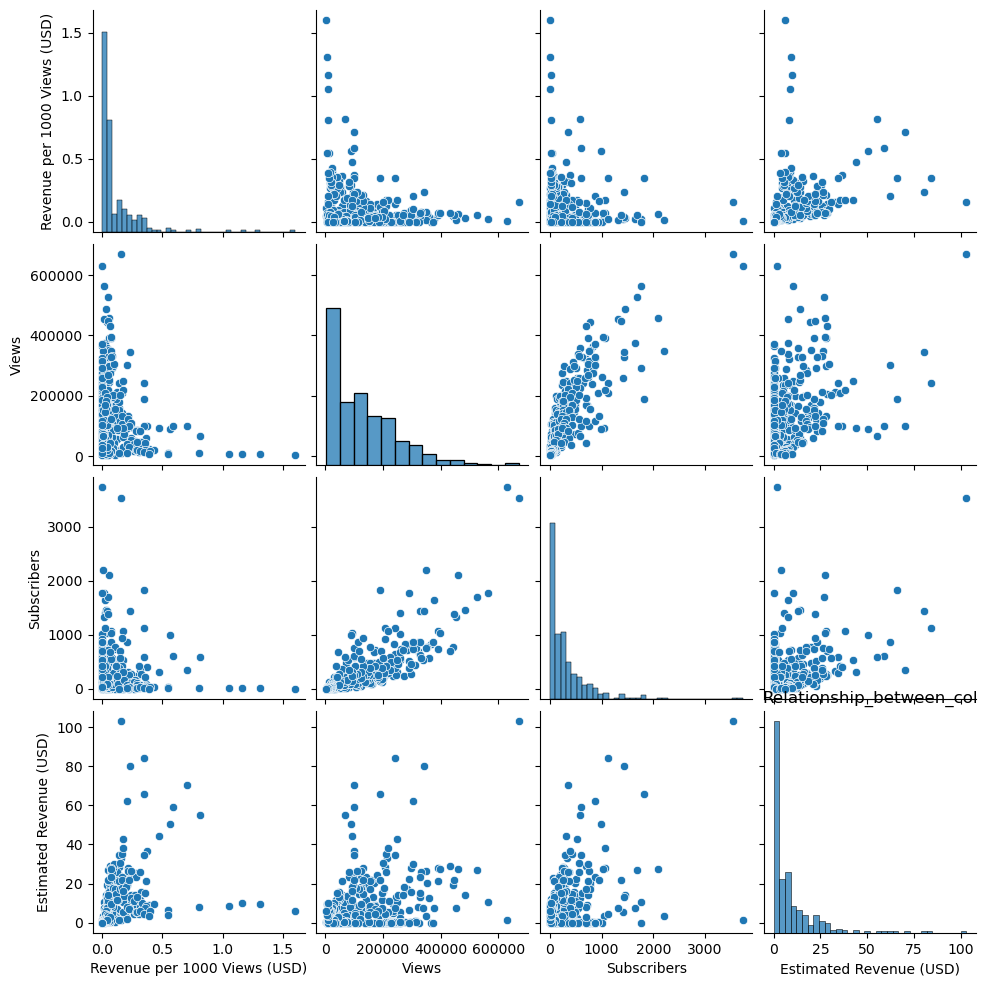

In [111]:
# Pairplot to visualize relationships
sns.pairplot(df[['Revenue per 1000 Views (USD)', 'Views', 'Subscribers', 'Estimated Revenue (USD)']])
plt.title('Relationship_between_col')
plt.show()

In [112]:
# changing date into datetime
df['Video Publish Time']=pd.to_datetime(df['Video Publish Time'])

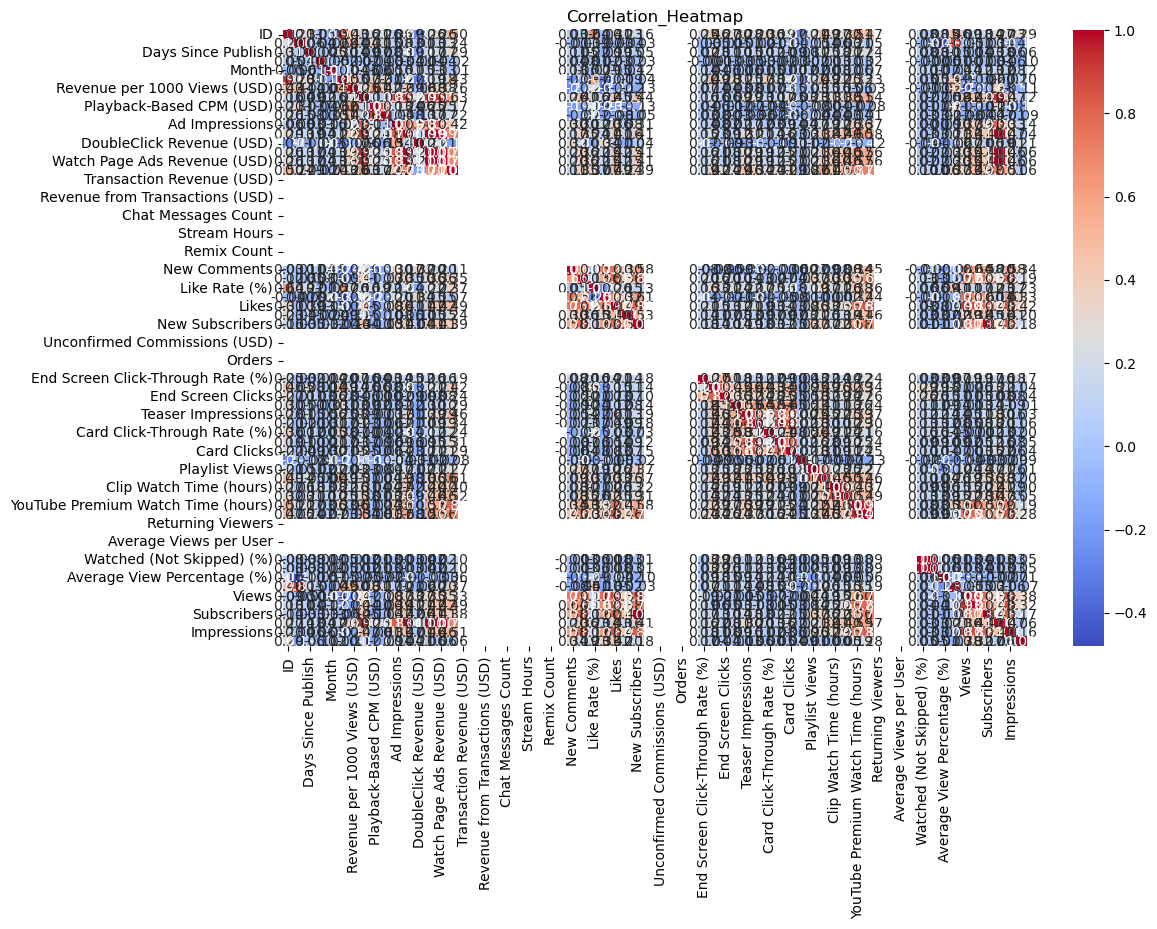

In [113]:
# heatmap for correlation
plt.figure(figsize=(12, 8)) 
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",cmap="coolwarm")
plt.title("Correlation_Heatmap") 
plt.show()

In [114]:
# Top performer by revenue
top_performer=df.sort_values(by='Estimated Revenue (USD)',ascending=False
).head(10)
print(top_performer[['ID', 'Estimated Revenue (USD)', 'Views', 'Subscribers']])

      ID  Estimated Revenue (USD)     Views  Subscribers
228  228                  103.117  670990.0       3538.0
257  257                   83.979  241060.0       1125.0
251  251                   80.265  343319.0       1437.0
289  289                   70.247   99196.0        350.0
278  278                   65.978  188324.0       1824.0
260  260                   62.047  302999.0        866.0
293  293                   59.058  101025.0        602.0
294  294                   55.040   67556.0        581.0
290  290                   50.344   89284.0        995.0
284  284                   44.228   93487.0        305.0


In [115]:
# creating new feature or columns

#creating revenue_per_view
df['Revenue_per_view']=df['Estimated Revenue (USD)'] / df['Views']
df['Revenue_per_view']=df['Revenue_per_view'].round(6)
df['Revenue_per_view'] = df['Revenue_per_view'].map('{:.6f}'.format)
df['Revenue_per_view']


0      0.000024
1      0.000056
2      0.000014
3      0.000004
4      0.000000
         ...   
359    0.000805
360    0.001049
361    0.001161
362    0.000546
363    0.001521
Name: Revenue_per_view, Length: 364, dtype: object

In [116]:
#creating_engagement_rate
df['Engagement_rate']=(df['Likes'] + df['Shares'] + df['New Comments']) / df['Views'] * 100
df['Engagement_rate']=df['Engagement_rate'].round(2)
df['Engagement_rate']

0      4.36
1      3.15
2      3.95
3      5.43
4      4.50
       ... 
359    8.45
360    7.72
361    9.28
362    7.58
363    9.85
Name: Engagement_rate, Length: 364, dtype: float64

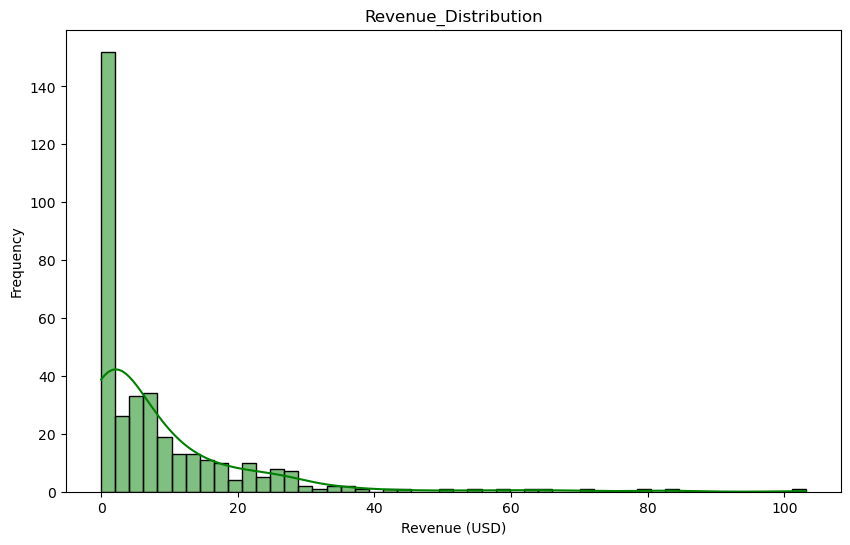

In [117]:
# Data Visualization

# revenue distribution
plt.figure(figsize=(10, 6)) 
sns.histplot(df['Estimated Revenue (USD)'], bins=50, kde=True, color='green')
plt.title("Revenue_Distribution") 
plt.xlabel("Revenue (USD)") 
plt.ylabel("Frequency") 
plt.show()

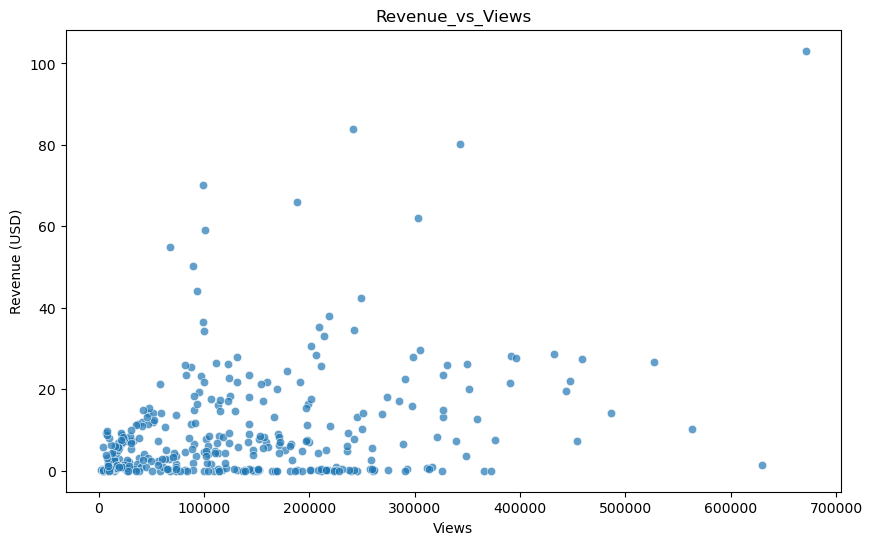

In [118]:
# Revenue vs views

plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=df['Views'], y=df['Estimated Revenue (USD)'], alpha=0.7) 
plt.title("Revenue_vs_Views") 
plt.xlabel("Views") 
plt.ylabel("Revenue (USD)") 
plt.show()

In [119]:
# Predictive_Model:Estimate_Revenue

#  Select features and target 
features = ['Views', 'Subscribers', 'Likes', 'Shares', 'New Comments', 'Engagement_rate'] 
target = 'Estimated Revenue (USD)' 
X= df[features] 
y= df[target] 

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

#Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42) 
model.fit(X_train, y_train)

# Predict on test data 
y_pred = model.predict(X_test) 

# Calculate performance metrics 
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print(f"Mean Squared Error: {mse:.2f}") 
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 75.47
R-squared: 0.13


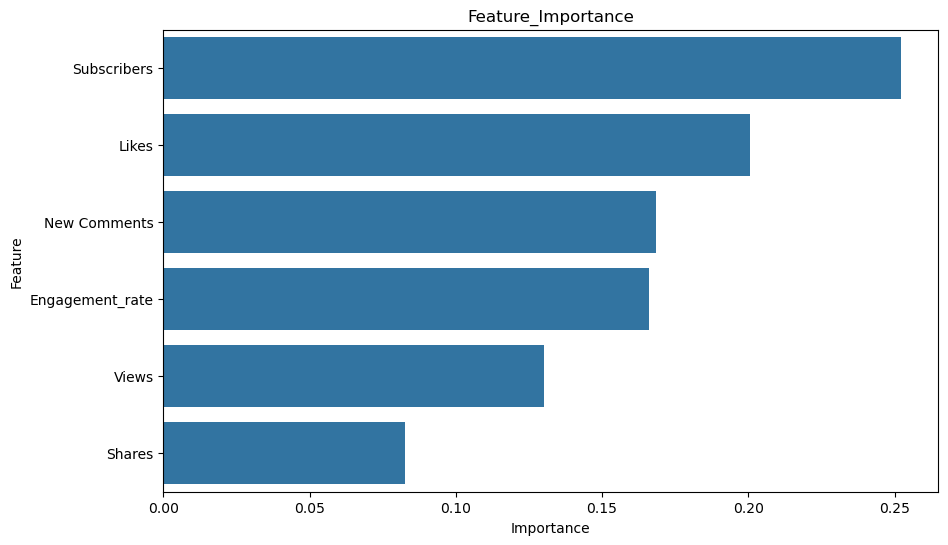

In [120]:
# insights and recommendation using plot

# Feature Importance 
importances = model.feature_importances_ 
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}) 
feature_importance_df =feature_importance_df.sort_values(by='Importance', ascending=False) 
# plotting features using bar
plt.figure(figsize=(10, 6)) 
sns.barplot(x='Importance', y='Feature', data=feature_importance_df) 
plt.title("Feature_Importance") 
plt.show()

In [121]:
# deployment

import joblib 
joblib.dump(model, 'youtube_channel_report.pkl')

['youtube_channel_report.pkl']

In [122]:
df=df.to_csv('cleaned_youtube_data.csv',index=False)